In [57]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import re

base_path = Path(r"D:\Beena\BCL_E197_198_199_analysis\input_data")
track_path = base_path / "tracks"

save_path = Path(r"D:\Beena\BCL_E197_198_199_analysis\plots")

import matplotlib as mpl

mpl.rc("axes", facecolor="#ffffff00", grid=False, edgecolor="k", labelcolor="k")
mpl.rc("figure", facecolor="#00000000", dpi=100)
mpl.rc(
    "axes.spines",
    top=True,
    right=True,
)
mpl.rc("xtick", color="k", bottom=True)
mpl.rc("ytick", color="k", left=True)
tracks = {}
stems = []
files = []

for f in track_path.glob("*.csv"):
    files.append(f)
    stems.append(f.stem)
    tracks[f.stem] = pd.read_csv(f)

px_um = 1.33  # microns per pixel
frame_min = 5 # minutes per frame
img_shape = (512, 512)

for k, df in enumerate(tracks.values()):

    df["px_x_centered"] = df["px_x"] - img_shape[1] / 2
    df["px_y_centered"] = df["px_y"] - img_shape[0] / 2

    df["um_x"] = df["px_x"] * px_um
    df["um_y"] = df["px_y"] * px_um

    df["um_x_centered"] = df["px_x_centered"] * px_um
    df["um_y_centered"] = df["px_y_centered"] * px_um

    df["time"] = df["frame"] * frame_min
    df["time_hour"] = df["time"] // 60

    df["dt"] = df.groupby("track_id")["time"].diff()
    df["dx"] = df.groupby("track_id")["um_x"].diff() / df["dt"]
    df["dy"] = df.groupby("track_id")["um_y"].diff() / df["dt"]
    df["dtot"] = np.sqrt(df["dx"]**2 + df["dy"]**2)

    df["radial_distance"] = np.sqrt(df["um_x_centered"]**2 + df["um_y_centered"]**2)
    df["radial_bin"] = (df["radial_distance"] // 20) * 20
    df["theta"] = np.arctan2(df["um_x_centered"], df["um_y_centered"])

    df["radial_velocity"] = df.groupby("track_id")["radial_distance"].diff() / df["dt"]

    df["source"] = k

    df["condition"] = re.match(r"BCL_E.+_(.+)_tracks", stems[k]).group(1)

    # plt.hist(df["dtot"], bins=50)
    # plt.show()

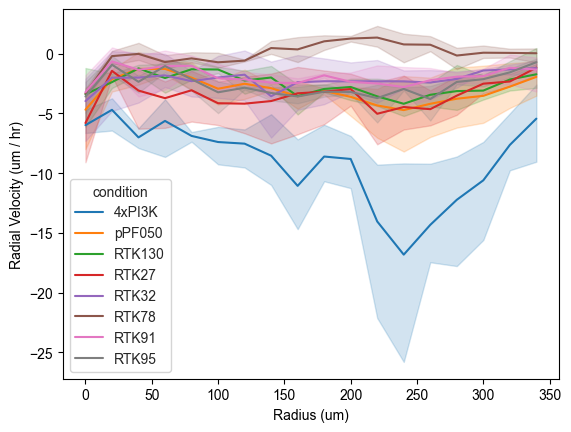

In [32]:
all_dfs = pd.concat(tracks, ignore_index=True).query("radial_bin < 350")

velocities = (all_dfs.groupby(["source", "radial_bin"])["radial_velocity"].mean() * 60).reset_index(level=0)
conditions = all_dfs.groupby(["source", "radial_bin"])["condition"].first().reset_index(level=0)

sns.lineplot(x=velocities.index, y=velocities["radial_velocity"], hue=conditions["condition"])
plt.xlabel("Radius (um)")
plt.ylabel("Radial Velocity (um / hr)")
plt.show()

Index(['label', 'area', 'px_y', 'px_x', 'frame', 'tree_id', 'track_id',
       'px_x_centered', 'px_y_centered', 'um_x', 'um_y', 'um_x_centered',
       'um_y_centered', 'time', 'time_hour', 'dt', 'dx', 'dy',
       'radial_distance', 'radial_bin', 'theta', 'radial_velocity', 'source',
       'condition'],
      dtype='object')
           source  radial_velocity
time_hour                         
0               0        -1.145853
1               0        -9.982934
2               0        -9.646260
3               0        -8.058883
4               0        -9.933613
...           ...              ...
8              23        -2.411214
9              23        -1.841107
10             23        -3.248569
11             23        -3.357219
12             23        -7.677134

[312 rows x 2 columns]


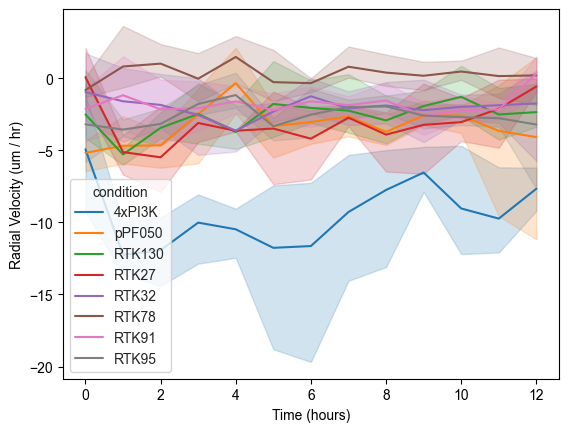

In [29]:
all_dfs = pd.concat(tracks, ignore_index=True).query("radial_bin < 350")
print(all_dfs.columns)
velocities = (all_dfs.groupby(["source", "time_hour"])["radial_velocity"].mean() * 60).reset_index(level=0)
conditions = all_dfs.groupby(["source", "time_hour"])["condition"].first().reset_index(level=0)

sns.lineplot(x=velocities.index, y=velocities["radial_velocity"], hue=conditions["condition"])
plt.xlabel("Time (hours)")
plt.ylabel("Radial Velocity (um / hr)")
plt.show()

Index(['label', 'area', 'px_y', 'px_x', 'frame', 'tree_id', 'track_id',
       'px_x_centered', 'px_y_centered', 'um_x', 'um_y', 'um_x_centered',
       'um_y_centered', 'time', 'time_hour', 'dt', 'dx', 'dy', 'dtot',
       'radial_distance', 'radial_bin', 'theta', 'radial_velocity', 'source',
       'condition'],
      dtype='object')
    source  radial_velocity
0        0         9.155469
1        1         2.319982
2        2         2.619073
3        3         1.739910
4        4         4.468454
5        5        -0.644905
6        6         1.143903
7        7         2.498195
8        8        18.852086
9        9         2.073809
10      10         5.891378
11      11         5.411548
12      12         0.855929
13      13        -0.212702
14      14         2.967455
15      15         4.110713
16      16        11.726365
17      17         4.632608
18      18         2.742356
19      19         6.560594
20      20         3.035609
21      21        -1.961753
22      22        

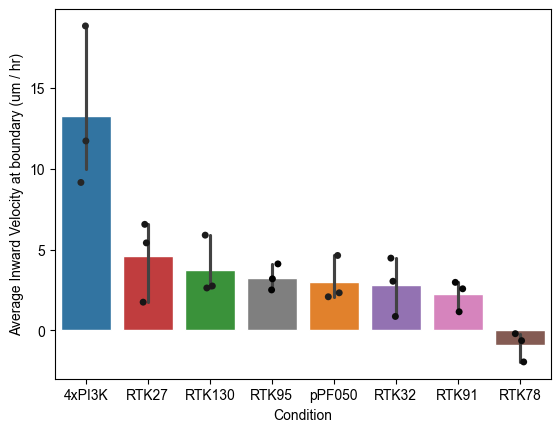

In [58]:
"""
FILTERING STEP HERE:
"""

all_dfs = pd.concat(tracks, ignore_index=True).query("radial_bin < 250 and radial_bin > 150 and "
                                                     "time_hour >= 2 and time_hour <= 6")
print(all_dfs.columns)
velocities = (-all_dfs.groupby(["source"])["radial_velocity"].mean() * 60).reset_index(level=0)
conditions = all_dfs.groupby(["source"])["condition"].first().reset_index(level=0)

# get average velocity of each movie in a dictionary, so we can sort the x axis of the bar plot
from collections import defaultdict
avg_velocities = defaultdict(list)
for vel, cond in zip(velocities["radial_velocity"], conditions["condition"]):
    avg_velocities[cond].append(vel)
avg_velocities = {c: np.mean(v) for c, v in avg_velocities.items()}
ordered_conditions = sorted(avg_velocities, key=avg_velocities.get, reverse=True)

print(velocities)

ax = sns.barplot(x=conditions["condition"], y=velocities["radial_velocity"], hue=conditions["condition"], order=ordered_conditions)
sns.stripplot(x=conditions["condition"], y=velocities["radial_velocity"], hue=conditions["condition"], order=ordered_conditions, palette="dark:k")

# from statannotations.Annotator import Annotator
# anchor = "4xPI3K"
# pairs = [(anchor, other) for other in ordered_conditions if other != anchor]
# annotator = Annotator(ax, pairs, x=conditions["condition"], y=velocities["radial_velocity"], order=ordered_conditions)
# annotator.configure(test='t-test_ind', text_format='star', loc='inside', line_height=0.02)
# annotator.apply_and_annotate()

plt.xlabel("Condition")
plt.ylabel("Average Inward Velocity at boundary (um / hr)")
plt.show()